# Component Ablation Study — 5-Fold CV (Task 1, Week 7)

Protocol: EuroSAT-MS **5-fold stratified cross-validation** (seed=42).
Each fold uses ~5 400 query images and ~5 400 gallery images (distinct folds).
Results are reported as **mean ± std across 5 folds**.

Artifacts read from `../results/ablation/component_ablation_5fold/`.

In [2]:
from pathlib import Path
import json, os, sys

os.environ.setdefault("XDG_CACHE_HOME", "/tmp/acivs_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/acivs_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR  = PROJECT_ROOT / "results" / "ablation" / "component_ablation_5fold"
ABLATION_DIR = PROJECT_ROOT / "results" / "ablation"
FOLD_CSV     = RESULTS_DIR / "fold_metrics.csv"
MANIFEST_JSON = RESULTS_DIR / "manifest.json"

for p in [FOLD_CSV, MANIFEST_JSON]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}. Run scripts/run_component_ablation_5fold.py first.")

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")


Project root: /Users/tienesng06/Desktop/ACIVS_ThayBach
Results dir:  /Users/tienesng06/Desktop/ACIVS_ThayBach/results/ablation/component_ablation_5fold


## Load fold metrics

In [3]:
df = pd.read_csv(FOLD_CSV)
print(f"Loaded {len(df)} rows  ×  {len(df.columns)} columns")
print(df.groupby("stage")["fold_id"].count().rename("n_folds"))
df.head(10)


Loaded 25 rows  ×  9 columns
stage
Ablation-Affinity    5
Ablation-Fiedler     5
Ablation-Full        5
Ablation-PBMean      5
Ablation-RGB         5
Name: n_folds, dtype: int64


,fold_id,stage,num_query,num_gallery,R@1,R@5,R@10,mAP,elapsed_ms
0,0,Ablation-RGB,5400,5400,80.388892,94.629627,97.203702,40.338091,838.5
1,0,Ablation-PBMean,5400,5400,86.500001,97.314817,98.611110,46.303394,3602.0
2,0,Ablation-Affinity,5400,5400,86.703706,97.296298,98.611110,46.438750,587.2
3,0,Ablation-Fiedler,5400,5400,84.500003,96.203703,98.092592,44.542382,3057.0
4,0,Ablation-Full,5400,5400,84.574074,96.296299,98.166668,45.040507,22745.4
5,1,Ablation-RGB,5400,5400,80.166668,95.722222,97.981483,40.306415,754.9
6,1,Ablation-PBMean,5400,5400,86.018521,97.296298,98.833334,46.185757,2080.1
7,1,Ablation-Affinity,5400,5400,86.444443,97.185183,98.851854,46.367978,577.0
8,1,Ablation-Fiedler,5400,5400,85.203701,96.370369,98.074073,44.346677,2255.2
9,1,Ablation-Full,5400,5400,85.500002,96.425927,98.037034,44.847428,16089.2


## Compute mean ± std across folds

In [4]:
STAGE_ORDER = [
    "Ablation-RGB",
    "Ablation-PBMean",
    "Ablation-Affinity",
    "Ablation-Fiedler",
    "Ablation-Full",
]
STAGE_LABELS = [
    "RGB baseline",
    "+ Per-band encode",
    "+ Affinity graph",
    "+ Fiedler",
    "+ Manifold opt (Full)",
]

metrics_cols = ["R@1", "R@5", "R@10", "mAP"]

summary_rows = []
for stage in STAGE_ORDER:
    sub = df[df["stage"] == stage]
    row = {"stage": stage}
    for col in metrics_cols:
        vals = sub[col].astype(float)
        row[f"{col}_mean"] = vals.mean()
        row[f"{col}_std"]  = vals.std(ddof=1)
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary.index = STAGE_LABELS

# Cumulative delta vs Stage 1 (RGB baseline)
rgb_r1 = summary.loc["RGB baseline", "R@1_mean"]
rgb_r10 = summary.loc["RGB baseline", "R@10_mean"]
summary["delta_R@1_vs_rgb"]  = summary["R@1_mean"]  - rgb_r1
summary["delta_R@10_vs_rgb"] = summary["R@10_mean"] - rgb_r10

# Incremental delta (vs previous stage)
summary["incr_delta_R@1"] = summary["R@1_mean"].diff().fillna(0.0)

summary


,stage,R@1_mean,R@1_std,R@5_mean,R@5_std,R@10_mean,R@10_std,mAP_mean,mAP_std,delta_R@1_vs_rgb,delta_R@10_vs_rgb,incr_delta_R@1
RGB baseline,Ablation-RGB,80.240742,0.685311,94.944445,0.479876,97.618518,0.376023,40.378456,0.306222,0.000000,0.000000,0.000000
+ Per-band encode,Ablation-PBMean,86.333334,0.255932,97.225927,0.155709,98.651851,0.112949,46.409869,0.292285,6.092592,1.033334,6.092592
+ Affinity graph,Ablation-Affinity,86.540741,0.176365,97.211112,0.130683,98.674074,0.111575,46.564491,0.284434,6.299999,1.055557,0.207406
+ Fiedler,Ablation-Fiedler,84.933333,0.614412,96.322222,0.171533,98.129629,0.160909,44.518905,0.295679,4.692591,0.511111,-1.607407
+ Manifold opt (Full),Ablation-Full,85.018519,0.619609,96.437037,0.244488,98.211111,0.217780,45.019475,0.305521,4.777777,0.592593,0.085186


## Ablation Table (paper-ready)

In [5]:
table_df = pd.DataFrame({
    "Component": STAGE_LABELS,
    "R@1 (%)":   [f'{summary.loc[l, "R@1_mean"]:.2f}±{summary.loc[l, "R@1_std"]:.2f}' for l in STAGE_LABELS],
    "R@10 (%)":  [f'{summary.loc[l, "R@10_mean"]:.2f}±{summary.loc[l, "R@10_std"]:.2f}' for l in STAGE_LABELS],
    "ΔR@1 vs RGB": [f'{summary.loc[l, "delta_R@1_vs_rgb"]:+.2f}%' for l in STAGE_LABELS],
    "Incr. ΔR@1":  [f'{summary.loc[l, "incr_delta_R@1"]:+.2f}%' for l in STAGE_LABELS],
})
display(table_df.set_index("Component").style.set_caption("Component Ablation Study — EuroSAT-MS 5-fold CV"))

# Save CSV
out_csv = ABLATION_DIR / "component_ablation_table_5fold.csv"
summary.to_csv(out_csv)
print(f"Saved → {out_csv}")


,R@1 (%),R@10 (%),ΔR@1 vs RGB,Incr. ΔR@1
Component,,,,
RGB baseline,80.24±0.69,97.62±0.38,+0.00%,+0.00%
+ Per-band encode,86.33±0.26,98.65±0.11,+6.09%,+6.09%
+ Affinity graph,86.54±0.18,98.67±0.11,+6.30%,+0.21%
+ Fiedler,84.93±0.61,98.13±0.16,+4.69%,-1.61%
+ Manifold opt (Full),85.02±0.62,98.21±0.22,+4.78%,+0.09%


Saved → /Users/tienesng06/Desktop/ACIVS_ThayBach/results/ablation/component_ablation_table_5fold.csv


## Monotonicity check

In [6]:
monotonic = all(summary["R@1_mean"].diff().dropna() >= 0)
cumulative_delta = summary.loc["+ Manifold opt (Full)", "delta_R@1_vs_rgb"]

print(f"Monotonic R@1 increase: {'YES ✓' if monotonic else 'NO ✗'}")
print(f"Cumulative ΔR@1 (Stage1→Stage5): {cumulative_delta:+.2f}%")
print(f"Paper target: ~+11.4%")

non_positive = summary[summary["incr_delta_R@1"] <= 0].index.tolist()
if non_positive:
    print(f"Stages with incremental delta ≤ 0: {non_positive}")
else:
    print("All stages contribute positively ✓")


Monotonic R@1 increase: NO ✗
Cumulative ΔR@1 (Stage1→Stage5): +4.78%
Paper target: ~+11.4%
Stages with incremental delta ≤ 0: ['RGB baseline', '+ Fiedler']


## Waterfall bar chart (with error bars)

Saved → /Users/tienesng06/Desktop/ACIVS_ThayBach/results/ablation/component_ablation_waterfall_5fold.png


/var/folders/_1/7696dy392rg6tzv9gs188d100000gn/T/ipykernel_30430/1348328965.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


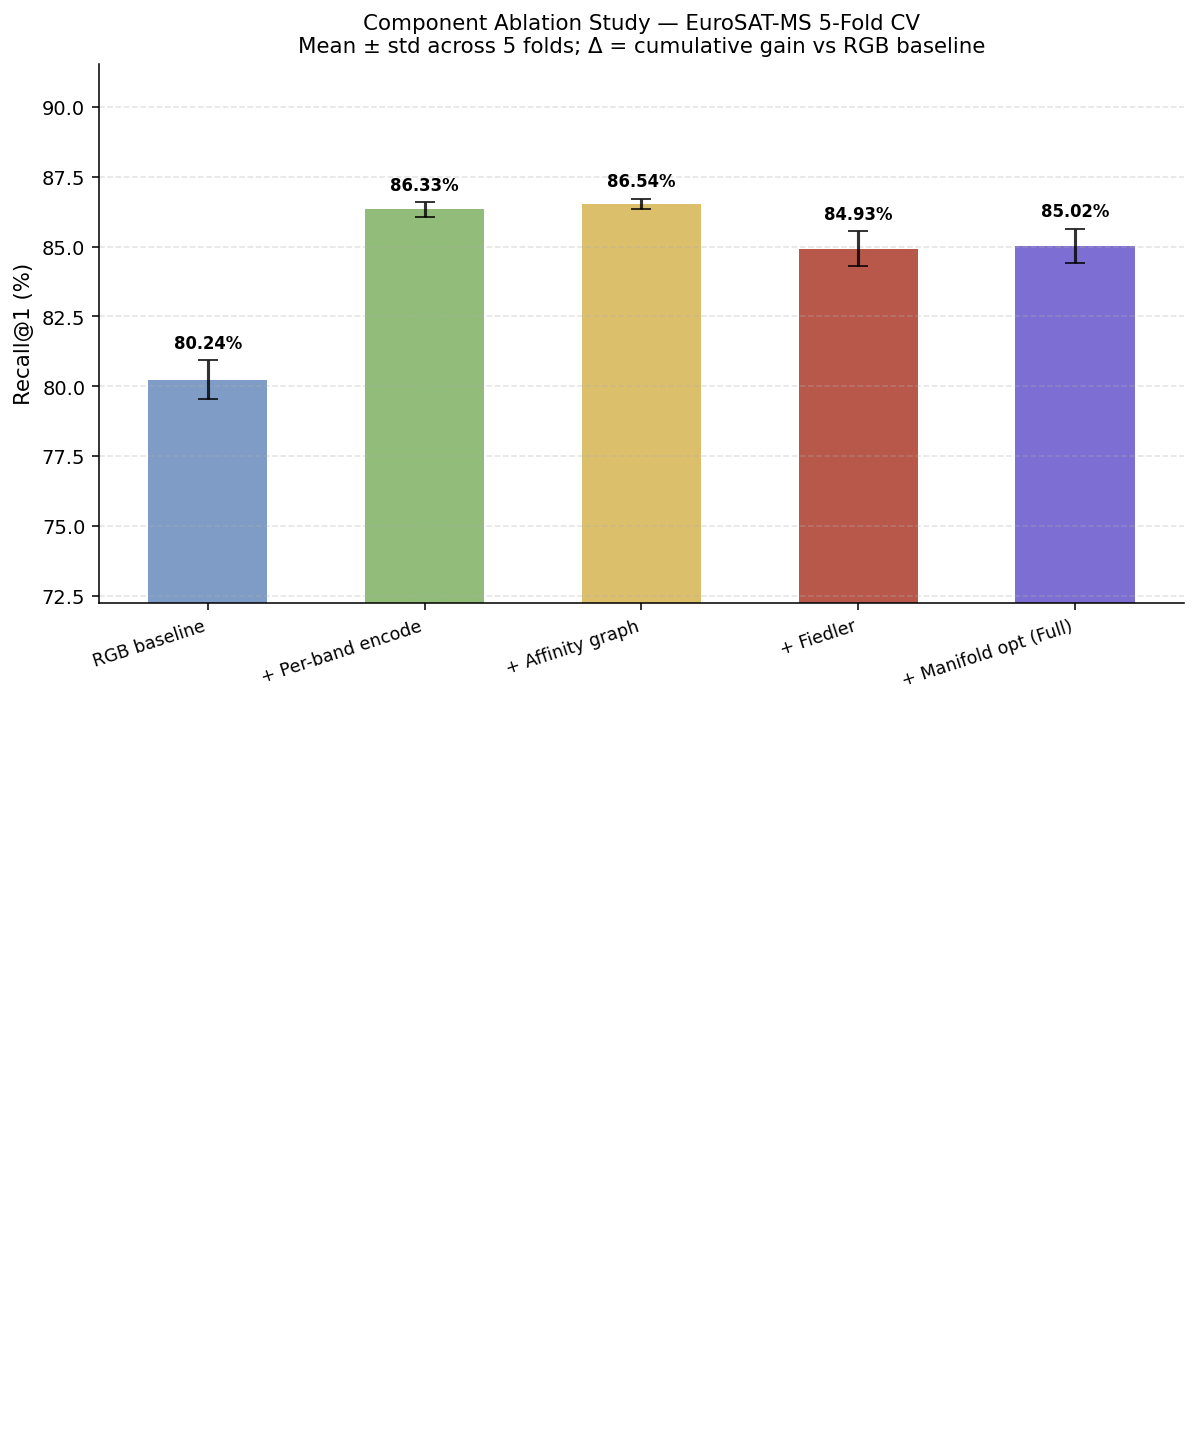

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=140)

x = np.arange(len(STAGE_LABELS))
bar_width = 0.55

means  = [summary.loc[l, "R@1_mean"] for l in STAGE_LABELS]
stds   = [summary.loc[l, "R@1_std"]  for l in STAGE_LABELS]
deltas = [summary.loc[l, "delta_R@1_vs_rgb"] for l in STAGE_LABELS]

colors = ["#6c8ebf", "#82b366", "#d6b656", "#ae4132", "#6a5acd"]
bars = ax.bar(x, means, width=bar_width, color=colors, alpha=0.88,
              yerr=stds, capsize=5, error_kw={"elinewidth": 1.6, "alpha": 0.8})

for xi, (mean_val, std_val, delta) in enumerate(zip(means, stds, deltas)):
    ax.text(xi, mean_val + std_val + 0.3, f"{mean_val:.2f}%",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    if xi > 0:
        ax.text(xi, mean_val / 2, f"{delta:+.1f}%",
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(STAGE_LABELS, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Recall@1 (%)", fontsize=11)
ax.set_title("Component Ablation Study — EuroSAT-MS 5-Fold CV\n"
             "Mean ± std across 5 folds; Δ = cumulative gain vs RGB baseline",
             fontsize=11)
ax.set_ylim(max(0, min(means) - 8), max(means) + 5)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

out_png = ABLATION_DIR / "component_ablation_waterfall_5fold.png"
fig.savefig(out_png, dpi=180, bbox_inches="tight")
print(f"Saved → {out_png}")
plt.show()


## Component contribution analysis

In [8]:
lines = [
    "# Component Contribution Analysis (5-Fold CV)",
    "",
    f"Protocol: EuroSAT-MS 5-fold stratified CV, seed=42.",
    f"Query text embeddings used for Affinity graph (Design Rule 1 / G7).",
    "",
    "| Component | R@1 (mean±std) | R@10 (mean±std) | ΔR@1 vs RGB |",
    "|-----------|---------------|----------------|-------------|",
]
for label in STAGE_LABELS:
    r1m = summary.loc[label, "R@1_mean"]
    r1s = summary.loc[label, "R@1_std"]
    r10m = summary.loc[label, "R@10_mean"]
    r10s = summary.loc[label, "R@10_std"]
    delta = summary.loc[label, "delta_R@1_vs_rgb"]
    lines.append(f"| {label} | {r1m:.2f}±{r1s:.2f} | {r10m:.2f}±{r10s:.2f} | {delta:+.2f}% |")

lines += [
    "",
    f"Cumulative R@1 delta (Stage1→Stage5): {cumulative_delta:+.2f}%",
    f"Paper target: ~+11.4%",
    f"Monotonic R@1 increase: {'yes' if monotonic else 'no'}",
    "",
    "Incremental R@1 contributions:",
]
for label in STAGE_LABELS[1:]:
    incr = summary.loc[label, "incr_delta_R@1"]
    lines.append(f"  {label}: {incr:+.2f} pp")

text = "\n".join(lines)
print(text)

out_txt = ABLATION_DIR / "component_contribution_analysis_5fold.txt"
out_txt.write_text(text)
print(f"\nSaved → {out_txt}")


# Component Contribution Analysis (5-Fold CV)

Protocol: EuroSAT-MS 5-fold stratified CV, seed=42.
Query text embeddings used for Affinity graph (Design Rule 1 / G7).

| Component | R@1 (mean±std) | R@10 (mean±std) | ΔR@1 vs RGB |
|-----------|---------------|----------------|-------------|
| RGB baseline | 80.24±0.69 | 97.62±0.38 | +0.00% |
| + Per-band encode | 86.33±0.26 | 98.65±0.11 | +6.09% |
| + Affinity graph | 86.54±0.18 | 98.67±0.11 | +6.30% |
| + Fiedler | 84.93±0.61 | 98.13±0.16 | +4.69% |
| + Manifold opt (Full) | 85.02±0.62 | 98.21±0.22 | +4.78% |

Cumulative R@1 delta (Stage1→Stage5): +4.78%
Paper target: ~+11.4%
Monotonic R@1 increase: no

Incremental R@1 contributions:
  + Per-band encode: +6.09 pp
  + Affinity graph: +0.21 pp
  + Fiedler: -1.61 pp
  + Manifold opt (Full): +0.09 pp

Saved → /Users/tienesng06/Desktop/ACIVS_ThayBach/results/ablation/component_contribution_analysis_5fold.txt
